# Synthetic Graph EDA

In [81]:
import os
from dgl import save_graphs, load_graphs
from dgl.data.utils import makedirs, save_info, load_info
import networkx as nx

In [82]:
# Config
ORG_DATASET = "reddit"
TASK = "hidden_labels"      # 'hidden_labels' or 'hidden_links'
SYNTHETIC_TYPE = f"bigg/{ORG_DATASET}/{TASK}"  
SYN_DATASET = "DEPRECATED_NOISE_SEPERATED_blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0"

## Original Graph

In [83]:
PATH = f'../datasets/original/{ORG_DATASET}'
original_graph, _ = load_graphs(PATH)
 
original_graph = original_graph[0]

In [84]:
org_graph_num_nodes = original_graph.num_nodes()
org_graph_num_edges = original_graph.num_edges()
org_graph_num_anomalies = original_graph.ndata['label'].tolist().count(1)

org_graph_ndata_keys = list(original_graph.ndata.keys())
org_graph_train_masks_shape = original_graph.ndata['train_masks'].shape

## Synthetic Graph

In [85]:
synthetic_path = f'../datasets/synthetic/{SYNTHETIC_TYPE}/{SYN_DATASET}'
synthetic_graph, _ = load_graphs(synthetic_path)

synthetic_graph = synthetic_graph[0]

In [86]:
syn_graph_num_nodes = synthetic_graph.num_nodes()
syn_graph_num_edges = synthetic_graph.num_edges()
syn_graph_num_anomalies = synthetic_graph.ndata['label'].tolist().count(1)

syn_graph_ndata_keys = list(synthetic_graph.ndata.keys())
if 'train_masks' in synthetic_graph.ndata:
    syn_graph_train_masks_shape = synthetic_graph.ndata['train_masks'].shape

## Summary

In [87]:
import pandas as pd
import torch

org_zero_indegree  = int((original_graph.in_degrees() == 0).sum())
syn_zero_indegree  = int((synthetic_graph.in_degrees() == 0).sum())

def split_summary(graph, mask_key):
    if mask_key not in graph.ndata:
        return "N/A"
    counts = graph.ndata[mask_key].float().sum(0)  # nodes per split
    return f"{counts.mean():.0f} (min {counts.min():.0f}, max {counts.max():.0f})"

summary = pd.DataFrame({
    "Original": [
        org_graph_num_nodes,
        org_graph_num_edges,
        org_graph_num_anomalies,
        f"⚠️{org_zero_indegree}" if org_zero_indegree > 0 else "N/A",
        str(org_graph_ndata_keys),
        str(tuple(org_graph_train_masks_shape)),
        split_summary(original_graph, "train_masks"),
        split_summary(original_graph, "val_masks"),
        split_summary(original_graph, "test_masks"),
    ],
    "Synthetic": [
        syn_graph_num_nodes,
        syn_graph_num_edges,
        syn_graph_num_anomalies,
        f"⚠️{syn_zero_indegree}" if syn_zero_indegree > 0 else "N/A",
        str(syn_graph_ndata_keys),
        str(tuple(syn_graph_train_masks_shape)) if "train_masks" in synthetic_graph.ndata else "N/A",
        split_summary(synthetic_graph, "train_masks"),
        split_summary(synthetic_graph, "val_masks"),
        split_summary(synthetic_graph, "test_masks"),
    ],
}, index=[
    "Nodes",
    "Edges",
    "Anomalies",
    "Nodes with 0 in-degree",
    "ndata keys",
    "train_masks shape",
    "Train nodes/split (mean, min, max)",
    "Val nodes/split (mean, min, max)",
    "Test nodes/split (mean, min, max)",
])

display(summary)

,Original,Synthetic
Nodes,10984,10984
Edges,168016,111996
Anomalies,366,263
Nodes with 0 in-degree,N/A,⚠️37
ndata keys,"['feature', 'label', 'train_masks', 'val_masks...","['test_masks', 'val_masks', 'train_masks', 'la..."
train_masks shape,"(10984, 20)","(10984, 20)"
"Train nodes/split (mean, min, max)","2246 (min 100, max 4393)","2246 (min 100, max 4393)"
"Val nodes/split (mean, min, max)","1148 (min 100, max 2196)","1148 (min 100, max 2196)"
"Test nodes/split (mean, min, max)","7590 (min 4395, max 10784)","0 (min 0, max 0)"


## Graph Statistics

**Convert dgl graph to NetworkX**

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Convert DGL graphs to simple undirected NetworkX graphs
# (to_networkx returns a MultiDiGraph; nx.Graph() collapses multi-edges)
org_nx = nx.Graph(original_graph.to_networkx())
syn_nx = nx.Graph(synthetic_graph.to_networkx())

### Degree Distribution

Original  — mean: 16.30, median: 8.0, max: 2557
Synthetic — mean: 10.20, median: 6.0, max: 1218


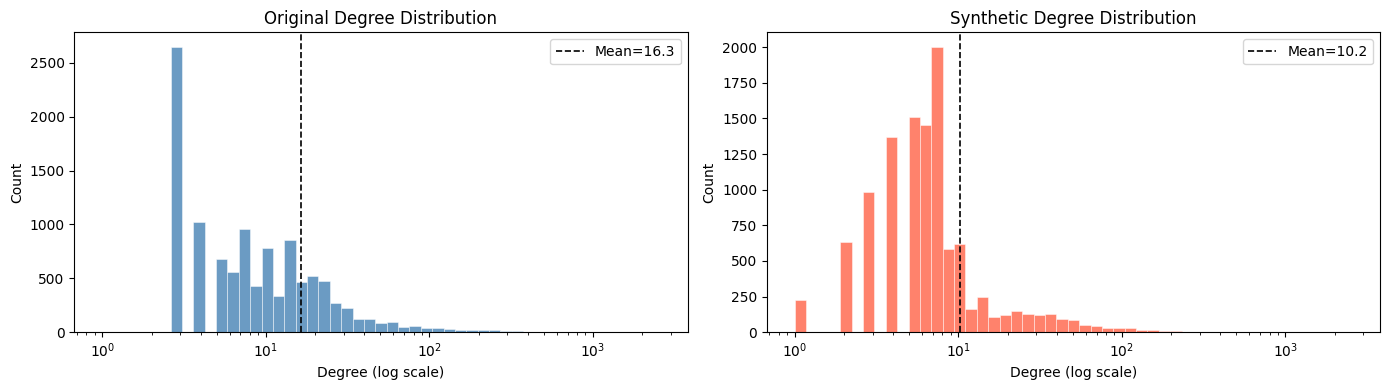

In [89]:
org_degrees = [d for _, d in org_nx.degree()]
syn_degrees = [d for _, d in syn_nx.degree()]

print(f"Original  — mean: {np.mean(org_degrees):.2f}, median: {np.median(org_degrees):.1f}, max: {max(org_degrees)}")
print(f"Synthetic — mean: {np.mean(syn_degrees):.2f}, median: {np.median(syn_degrees):.1f}, max: {max(syn_degrees)}")

max_degree = max(max(org_degrees), max(syn_degrees))
bins = np.logspace(0, np.log10(max_degree + 1), 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, degrees, label, color in zip(
    axes,
    [org_degrees, syn_degrees],
    ["Original", "Synthetic"],
    ["steelblue", "tomato"],
):
    ax.hist(degrees, bins=bins, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
    ax.set_xscale("log")
    ax.set_xlabel("Degree (log scale)")
    ax.set_ylabel("Count")
    ax.set_title(f"{label} Degree Distribution")
    ax.axvline(np.mean(degrees), color="black", linestyle="--", linewidth=1.2, label=f"Mean={np.mean(degrees):.1f}")
    ax.legend()

plt.tight_layout()
plt.show()

### Clustering Coefficient

Original  — average clustering coefficient: 0.0000
Synthetic — average clustering coefficient: 0.0029


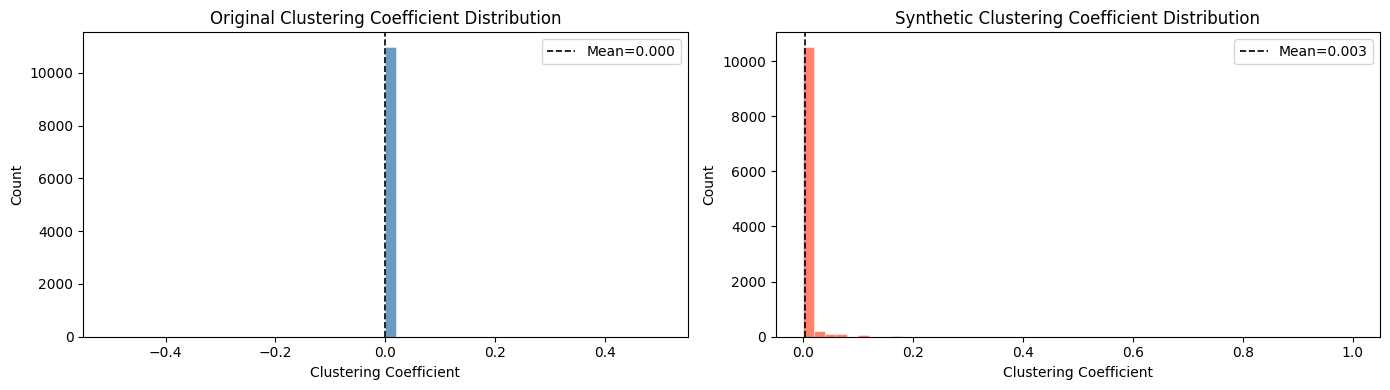

In [90]:
# Global (average) clustering coefficient
# Note: can be slow on large graphs; uses approximation via sampling if needed
org_avg_cc = nx.average_clustering(org_nx)
syn_avg_cc = nx.average_clustering(syn_nx)

print(f"Original  — average clustering coefficient: {org_avg_cc:.4f}")
print(f"Synthetic — average clustering coefficient: {syn_avg_cc:.4f}")

# Per-node distribution
org_cc = list(nx.clustering(org_nx).values())
syn_cc = list(nx.clustering(syn_nx).values())

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, cc_vals, label, color in zip(
    axes,
    [org_cc, syn_cc],
    ["Original", "Synthetic"],
    ["steelblue", "tomato"],
):
    ax.hist(cc_vals, bins=50, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
    ax.set_xlabel("Clustering Coefficient")
    ax.set_ylabel("Count")
    ax.set_title(f"{label} Clustering Coefficient Distribution")
    ax.axvline(np.mean(cc_vals), color="black", linestyle="--", linewidth=1.2, label=f"Mean={np.mean(cc_vals):.3f}")
    ax.legend()

plt.tight_layout()
plt.show()

### Feature Distribution

In [91]:
org_feats = original_graph.ndata['feature'].numpy()   # shape [N, feat_dim]
syn_feats = synthetic_graph.ndata['feature'].numpy()

feat_dim = org_feats.shape[1]
print(f"Feature dimensionality: {feat_dim}")

# Summary stats per feature
print(f"\n{'Feature':>8} | {'Org mean':>10} {'Org std':>8} | {'Syn mean':>10} {'Syn std':>8}")
print("-" * 56)
for i in range(feat_dim):
    print(f"{i:>8} | {org_feats[:, i].mean():>10.4f} {org_feats[:, i].std():>8.4f} | "
          f"{syn_feats[:, i].mean():>10.4f} {syn_feats[:, i].std():>8.4f}")

Feature dimensionality: 64

 Feature |   Org mean  Org std |   Syn mean  Syn std
--------------------------------------------------------
       0 |     0.0156   0.0023 |     0.0161   0.0029
       1 |     0.0157   0.0017 |     0.0157   0.0022
       2 |     0.0157   0.0020 |     0.0160   0.0025
       3 |     0.0157   0.0018 |     0.0164   0.0028
       4 |     0.0156   0.0021 |     0.0143   0.0029
       5 |     0.0156   0.0020 |     0.0137   0.0026
       6 |     0.0156   0.0023 |     0.0148   0.0025
       7 |     0.0156   0.0022 |     0.0169   0.0029
       8 |     0.0156   0.0019 |     0.0159   0.0025
       9 |     0.0157   0.0019 |     0.0139   0.0027
      10 |     0.0156   0.0020 |     0.0163   0.0023
      11 |     0.0156   0.0016 |     0.0167   0.0029
      12 |     0.0157   0.0015 |     0.0151   0.0024
      13 |     0.0156   0.0021 |     0.0151   0.0025
      14 |     0.0155   0.0019 |     0.0155   0.0023
      15 |     0.0157   0.0021 |     0.0164   0.0026
      16 |    

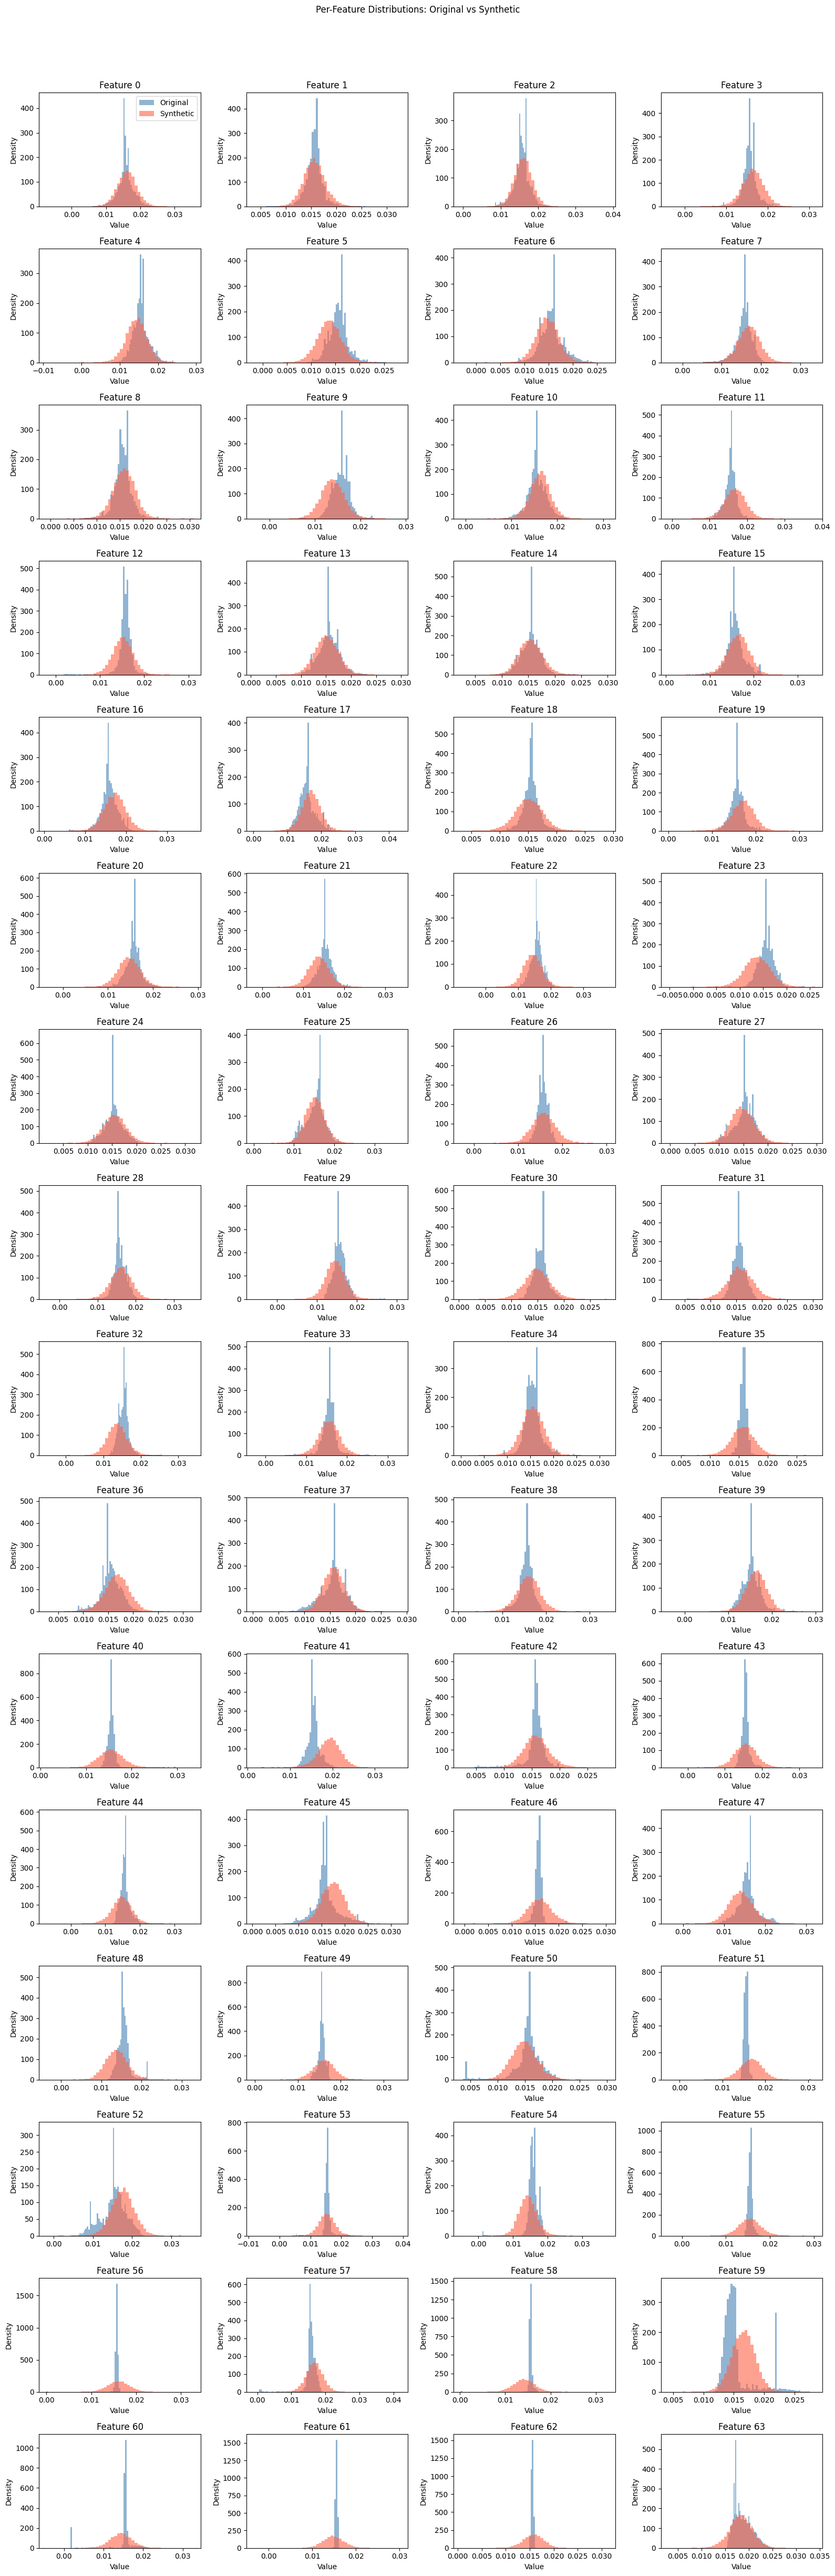

In [92]:
# Plot per-feature distributions (original vs synthetic overlay)
ncols = 4
nrows = (feat_dim + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i in range(feat_dim):
    ax = axes[i]
    ax.hist(org_feats[:, i], bins=50, alpha=0.6, label="Original", color="steelblue", density=True)
    ax.hist(syn_feats[:, i], bins=50, alpha=0.6, label="Synthetic", color="tomato", density=True)
    ax.set_title(f"Feature {i}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    if i == 0:
        ax.legend()

# Hide unused subplots
for j in range(feat_dim, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Per-Feature Distributions: Original vs Synthetic", y=1.02)
plt.tight_layout()
plt.show()

## Add Train/Val/Test Masks

In [14]:
# import torch

# num_nodes = synthetic_graph.num_nodes()
# num_splits = graph.ndata['train_masks'].shape[1]  # 20

# synthetic_graph.ndata['train_masks'] = torch.ones(num_nodes, num_splits, dtype=torch.uint8)
# synthetic_graph.ndata['val_masks'] = torch.zeros(num_nodes, num_splits, dtype=torch.uint8)
# synthetic_graph.ndata['test_masks'] = torch.zeros(num_nodes, num_splits, dtype=torch.uint8)

# save_graphs(synthetic_path, [synthetic_graph])
# print("Saved with masks:", list(synthetic_graph.ndata.keys()))